# CIC-IDS2017 data

In [2]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from tqdm.auto import tqdm

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

CSV_FOLDER = PROJECT_ROOT / "dataset/CSVs/MachineLearningCSV"
PROCESSED_FOLDER = PROJECT_ROOT / "dataset/processed"
print("Project:", PROJECT_ROOT)

Project: d:\Learn\Master\SBU\Network Security\Final Project\CICIDS2017-ML-IDS


## 1. Available CSV files

Each CSV represents network flows captured during one part of the CIC-IDS2017 week.

In [3]:
csv_files = sorted(CSV_FOLDER.glob("*.csv"))

file_table = pd.DataFrame({
    "file": [file.name for file in csv_files],
    "size_mb": [file.stat().st_size / 1024**2 for file in csv_files],
})
file_table.loc["Total", "size_mb"] = file_table["size_mb"].sum()
file_table

,file,size_mb
0,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,73.551
1,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,73.343
2,Friday-WorkingHours-Morning.pcap_ISCX.csv,55.615
3,Monday-WorkingHours.pcap_ISCX.csv,168.732
4,Thursday-WorkingHours-Afternoon-Infilteration....,79.253
5,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,49.613
6,Tuesday-WorkingHours.pcap_ISCX.csv,128.821
7,Wednesday-workingHours.pcap_ISCX.csv,214.735
Total,NaN,843.664


## 2. Raw rows and columns

One row represents one bidirectional network flow. The columns describe its destination port, duration, packet counts, byte counts, packet sizes, TCP flags, inter-arrival times, active/idle times, and label.

In [4]:
raw_sample = pd.read_csv(csv_files[0], nrows=20_000, low_memory=False)
raw_sample.columns = raw_sample.columns.str.strip()

print(f"Sample rows: {len(raw_sample):,}")
print(f"Raw columns: {len(raw_sample.columns)}")
display(raw_sample.head())

Sample rows: 20,000
Raw columns: 79


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.000,0.000,0,0,0.000,0.000,"4,000,000.000","666,666.667",3.000,0.000,3,3,3,3.000,0.000,3,3,0,0.000,0.000,0,0,0,0,0,0,40,0,"666,666.667",0.000,6,6,6.000,0.000,0.000,0,0,0,0,1,0,0,0,0,9.000,6.000,0.000,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.000,0.000,0,0,0.000,0.000,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.000,0.000,6,6,6.000,0.000,"110,091.743","18,348.624",109.000,0.000,109,109,0,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,0,0,20,20,"9,174.312","9,174.312",6,6,6.000,0.000,0.000,0,0,0,0,1,1,0,0,1,9.000,6.000,6.000,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.000,0.000,0,0,0.000,0.000,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.000,0.000,6,6,6.000,0.000,"230,769.231","38,461.538",52.000,0.000,52,52,0,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,0,0,20,20,"19,230.769","19,230.769",6,6,6.000,0.000,0.000,0,0,0,0,1,1,0,0,1,9.000,6.000,6.000,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.000,0.000,0,0,0.000,0.000,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.000,0.000,6,6,6.000,0.000,"352,941.177","58,823.529",34.000,0.000,34,34,0,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,0,0,20,20,"29,411.765","29,411.765",6,6,6.000,0.000,0.000,0,0,0,0,1,1,0,0,1,9.000,6.000,6.000,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.000,0.000,0,0,0.000,0.000,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.000,0.000,0,0,0.000,0.000,"4,000,000.000","666,666.667",3.000,0.000,3,3,3,3.000,0.000,3,3,0,0.000,0.000,0,0,0,0,0,0,40,0,"666,666.667",0.000,6,6,6.000,0.000,0.000,0,0,0,0,1,0,0,0,0,9.000,6.000,0.000,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.000,0.000,0,0,0.000,0.000,0,0,BENIGN


In [5]:
column_table = pd.DataFrame({
    "column": raw_sample.columns,
    "data_type": raw_sample.dtypes.astype(str).values,
    "example": [raw_sample[column].iloc[0] for column in raw_sample.columns],
})
column_table

,column,data_type,example
0,Destination Port,int64,54865
1,Flow Duration,int64,3
2,Total Fwd Packets,int64,2
3,Total Backward Packets,int64,0
4,Total Length of Fwd Packets,int64,12
...,...,...,...
74,Idle Mean,float64,0.000
75,Idle Std,float64,0.000
76,Idle Max,int64,0
77,Idle Min,int64,0


## 3. Traffic labels

`BENIGN` means normal traffic. Every other value identifies an attack. The loop reads only the label column, so it is much lighter than loading every feature.

In [6]:
all_labels = []
for file in tqdm(csv_files, desc="Reading labels", unit="file"):
    labels = pd.read_csv(
        file,
        usecols=lambda column: column.strip() == "Label",
    ).iloc[:, 0]
    labels = (
        labels.astype("string")
        .str.strip()
        .str.replace("�", "-", regex=False)
        .str.replace(r"\s*-\s*", " - ", regex=True)
    )
    all_labels.append(labels)

label_counts = pd.concat(all_labels).value_counts().rename_axis("label").to_frame("rows")
label_counts["percent"] = 100 * label_counts["rows"] / label_counts["rows"].sum()
label_counts

Reading labels: 100%|██████████| 8/8 [00:05<00:00,  1.48file/s]


,rows,percent
label,,
BENIGN,2273097,80.300
DoS Hulk,231073,8.163
PortScan,158930,5.614
DDoS,128027,4.523
DoS GoldenEye,10293,0.364
FTP - Patator,7938,0.280
SSH - Patator,5897,0.208
DoS slowloris,5796,0.205
DoS Slowhttptest,5499,0.194


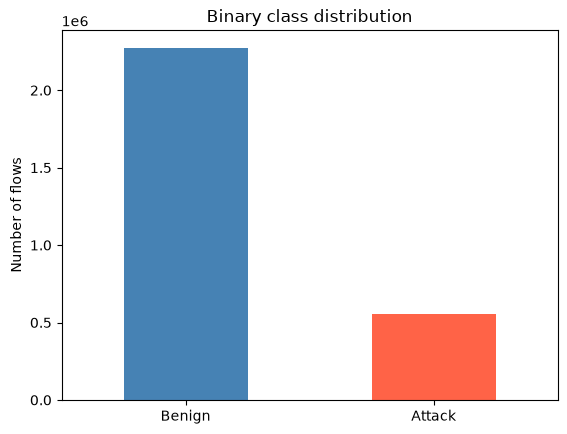

In [7]:
binary_counts = pd.Series({
    "Benign": label_counts.loc["BENIGN", "rows"],
    "Attack": label_counts.drop(index="BENIGN")["rows"].sum(),
})

binary_counts.plot(kind="bar", color=["steelblue", "tomato"], rot=0)
plt.title("Binary class distribution")
plt.ylabel("Number of flows")
plt.show()

## 4. Cleaning results

The preprocessing report records how many invalid and duplicate rows were removed before the split.

In [8]:
report_path = PROCESSED_FOLDER / "preprocessing_report.json"
if not report_path.exists():
    raise FileNotFoundError("Run 'uv run python prepare_data.py' first.")

report = json.loads(report_path.read_text(encoding="utf-8"))
pd.Series(report, name="rows/value").to_frame()

,rows/value
input,2830743
invalid,2867
duplicates,307078
retained,2520798
train,2016638
test,504160
features,77


## 5. Processed datasets

The Parquet metadata gives the complete dimensions without loading all rows. A single row group is enough for visual exploration. Feature values are standardized; values near zero are close to the training mean.

In [9]:
train_path = PROCESSED_FOLDER / "train.parquet"
test_path = PROCESSED_FOLDER / "test.parquet"

def parquet_info(path):
    parquet = pq.ParquetFile(path)
    return {
        "file": path.name,
        "rows": parquet.metadata.num_rows,
        "columns": parquet.metadata.num_columns,
        "size_mb": path.stat().st_size / 1024**2,
    }

pd.DataFrame([parquet_info(train_path), parquet_info(test_path)])

,file,rows,columns,size_mb
0,train.parquet,2016638,79,211.290
1,test.parquet,504160,79,53.429


In [10]:
train_file = pq.ParquetFile(train_path)
train_sample = train_file.read_row_group(0).to_pandas().head(50_000)

print(f"Loaded {len(train_sample):,} rows for exploration")
display(train_sample.head())

Loaded 50,000 rows for exploration


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,attack_label,is_attack
0,-0.285,-0.471,-0.012,-0.010,-0.094,-0.008,-0.306,-0.316,-0.325,-0.261,-0.475,-0.524,-0.529,-0.427,-0.049,-0.050,-0.308,-0.388,-0.401,-0.057,-0.462,-0.291,-0.362,-0.394,-0.126,-0.368,-0.216,-0.252,-0.291,-0.124,-0.226,0.000,-0.006,0.000,0.002,0.002,-0.115,0.314,-0.655,-0.499,-0.593,-0.494,-0.314,-0.182,-0.226,-0.017,1.536,-0.673,-0.336,-0.006,-0.017,0.429,-0.606,-0.325,-0.529,0.000,0.000,0.000,0.000,0.000,0.000,-0.012,-0.094,-0.010,-0.008,1.500,-0.250,-0.009,0.003,-0.136,-0.111,-0.159,-0.109,-0.376,-0.116,-0.381,-0.362,PortScan,1
1,2.182,-0.471,-0.012,-0.010,-0.093,-0.008,-0.298,-0.217,-0.294,-0.261,-0.475,-0.524,-0.529,-0.427,-0.044,-0.028,-0.308,-0.388,-0.401,-0.057,-0.462,-0.291,-0.362,-0.394,-0.126,-0.368,-0.216,-0.252,-0.291,-0.124,-0.226,0.000,-0.006,0.000,0.002,0.002,-0.104,0.375,-0.422,-0.499,-0.580,-0.500,-0.314,-0.182,-0.226,-0.017,-0.651,1.486,2.977,-0.006,-0.017,0.429,-0.589,-0.294,-0.529,0.000,0.000,0.000,0.000,0.000,0.000,-0.012,-0.093,-0.010,-0.008,-0.494,-0.221,-0.009,0.003,-0.136,-0.111,-0.159,-0.109,-0.376,-0.116,-0.381,-0.362,BENIGN,0
2,-0.453,-0.469,-0.009,-0.007,-0.090,-0.003,-0.280,-0.316,-0.281,-0.226,5.210,-0.609,4.050,6.151,-0.046,-0.233,-0.306,-0.385,-0.399,-0.057,-0.462,-0.291,-0.362,-0.394,-0.126,-0.365,-0.214,-0.246,-0.287,-0.124,-0.226,0.000,-0.006,0.000,0.002,0.002,-0.211,-0.169,-0.655,4.964,3.971,5.702,9.366,-0.182,-0.226,-0.017,1.536,-0.673,-0.336,-0.006,-0.017,0.429,4.198,-0.281,4.050,0.000,0.000,0.000,0.000,0.000,0.000,-0.009,-0.090,-0.007,-0.003,0.063,-0.224,-0.006,0.003,-0.136,-0.111,-0.159,-0.109,-0.376,-0.116,-0.381,-0.362,DDoS,1
3,-0.434,-0.457,-0.002,-0.003,-0.015,-0.006,-0.039,-0.316,-0.037,0.017,0.223,-0.609,0.247,0.304,-0.053,-0.233,-0.302,-0.381,-0.392,-0.057,-0.448,-0.285,-0.354,-0.385,-0.126,-0.356,-0.211,-0.238,-0.276,-0.124,-0.226,0.000,-0.006,0.000,0.002,0.002,-0.211,-0.170,-0.655,0.173,0.224,0.242,-0.176,-0.182,-0.226,-0.017,1.536,-0.673,-0.336,-0.006,-0.017,0.429,0.186,-0.037,0.247,0.000,0.000,0.000,0.000,0.000,0.000,-0.002,-0.015,-0.003,-0.006,0.063,-0.210,-0.003,0.003,-0.136,-0.111,-0.159,-0.109,-0.376,-0.116,-0.381,-0.362,BENIGN,0
4,-0.434,-0.460,-0.001,-0.003,-0.006,-0.005,-0.040,-0.316,-0.034,0.009,0.387,-0.609,0.609,0.456,-0.052,-0.233,-0.303,-0.384,-0.396,-0.057,-0.451,-0.287,-0.357,-0.387,-0.126,-0.360,-0.213,-0.245,-0.285,-0.124,-0.226,0.000,-0.006,0.000,0.002,0.002,-0.211,-0.170,-0.655,0.331,0.517,0.429,-0.097,-0.182,-0.226,-0.017,1.536,-0.673,-0.336,-0.006,-0.017,-1.002,0.467,-0.034,0.609,0.000,0.000,0.000,0.000,0.000,0.000,-0.001,-0.006,-0.003,-0.005,0.063,-0.249,0.004,0.003,-0.136,-0.111,-0.159,-0.109,-0.376,-0.116,-0.381,-0.362,BENIGN,0


In [11]:
feature_columns = [
    column for column in train_sample.columns
    if column not in {"attack_label", "is_attack"}
]

quality_check = {
    "sample_rows": len(train_sample),
    "feature_columns": len(feature_columns),
    "missing_cells": int(train_sample.isna().sum().sum()),
    "infinite_feature_cells": int(np.isinf(train_sample[feature_columns].to_numpy()).sum()),
}
pd.Series(quality_check).to_frame("value")

,value
sample_rows,50000
feature_columns,77
missing_cells,0
infinite_feature_cells,0


## 6. Important feature examples

In [12]:
interesting_features = [
    "Destination Port",
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Flow Bytes/s",
    "Packet Length Mean",
]
train_sample[interesting_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Destination Port,"50,000.000",0.004,1.004,-0.457,-0.454,-0.453,-0.434,2.991
Flow Duration,"50,000.000",-0.004,0.995,-0.471,-0.471,-0.470,-0.320,2.935
Total Fwd Packets,"50,000.000",-0.001,0.886,-0.012,-0.010,-0.010,-0.006,197.756
Total Backward Packets,"50,000.000",-0.001,0.933,-0.011,-0.010,-0.009,-0.006,208.236
Flow Bytes/s,"50,000.000",-0.004,0.923,-0.053,-0.053,-0.053,-0.049,78.673
Packet Length Mean,"50,000.000",-0.005,0.993,-0.599,-0.580,-0.400,-0.124,7.000


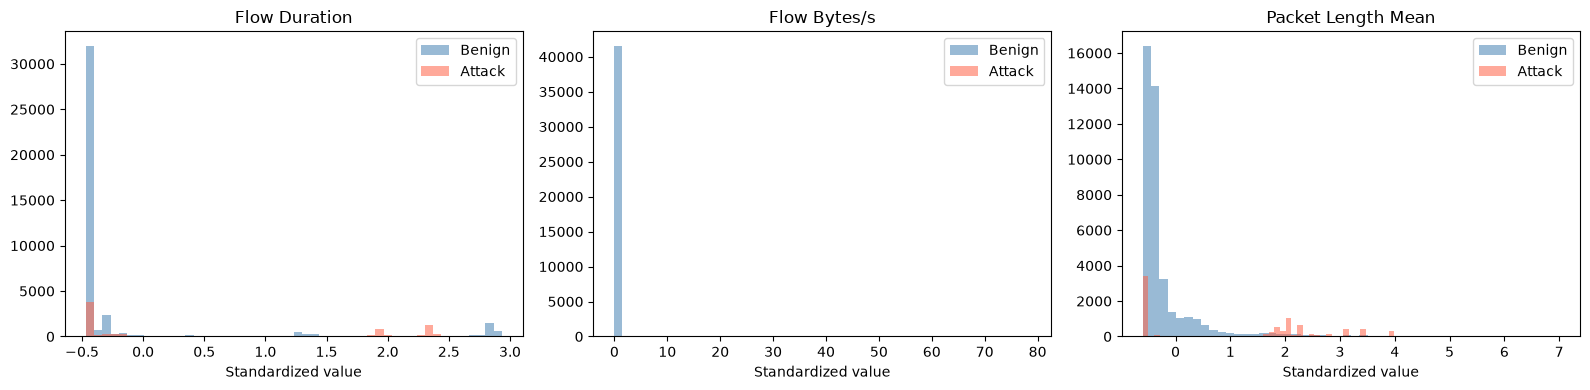

In [13]:
plot_features = ["Flow Duration", "Flow Bytes/s", "Packet Length Mean"]
colors = {0: "steelblue", 1: "tomato"}
names = {0: "Benign", 1: "Attack"}

fig, axes = plt.subplots(1, len(plot_features), figsize=(16, 4))
for axis, feature in zip(axes, plot_features):
    for label in [0, 1]:
        values = train_sample.loc[train_sample["is_attack"] == label, feature]
        axis.hist(values, bins=50, alpha=0.55, label=names[label], color=colors[label])
    axis.set_title(feature)
    axis.set_xlabel("Standardized value")
    axis.legend()

plt.tight_layout()
plt.show()

## What this tells us

- The dataset is flow-based: one row is a network conversation, not one packet.
- There are many more benign flows than attack flows, so F1 and recall will matter in addition to accuracy.
- The processed data has 77 numeric model features plus `attack_label` and `is_attack`.
- `attack_label` preserves the attack name for analysis; `is_attack` is the binary model target.
- Feature selection should be fitted using training data only.